<a href="https://colab.research.google.com/github/Kenny625819/Applied-Data-Science/blob/main/BJJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Strict main analysis
{'k': 6, 'events_total': 537, 'n_total': 608, 'crude_rate': 0.8832236842105263, 'pooled_rate': 0.8635278660565769, 'ci_low': 0.7387676136097742, 'ci_high': 0.934025683392459, 'pi_low': 0.5123381414452661, 'pi_high': 0.9744303976718156, 'tau2': 0.6704015007255664, 'Q': 32.13114161385751, 'df': 5, 'I2': 84.43877263967615}

Expanded sensitivity analysis
{'k': 14, 'events_total': 655, 'n_total': 748, 'crude_rate': 0.8756684491978609, 'pooled_rate': 0.8417959411522155, 'ci_low': 0.7649155289708793, 'ci_high': 0.8969220388865622, 'pi_low': 0.5642896751871037, 'pi_high': 0.9562577798182701, 'tau2': 0.4568007027504504, 'Q': 42.58002653518664, 'df': 13, 'I2': 69.46925340862046}

Prediction intervals
Strict analysis: pooled 86.4% (95% CI 73.9–93.4; 95% PI 51.2–97.4)
Expanded analysis: pooled 84.2% (95% CI 76.5–89.7; 95% PI 56.4–95.6)


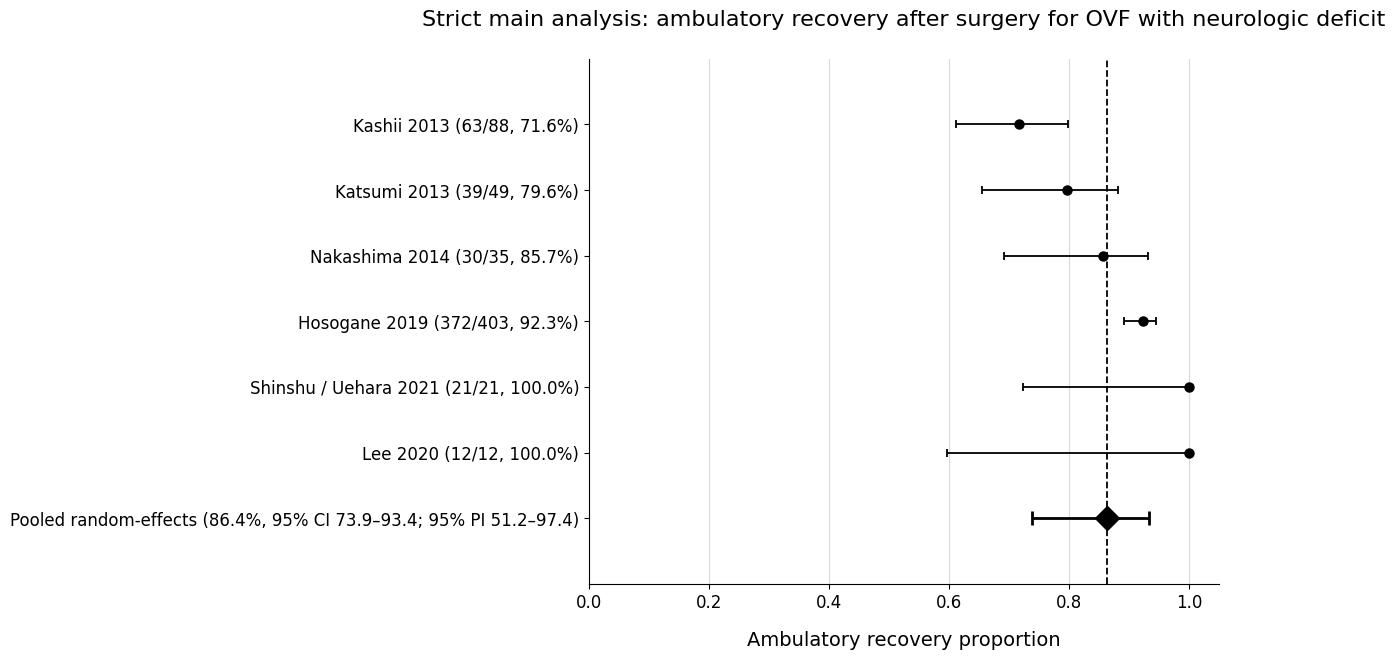

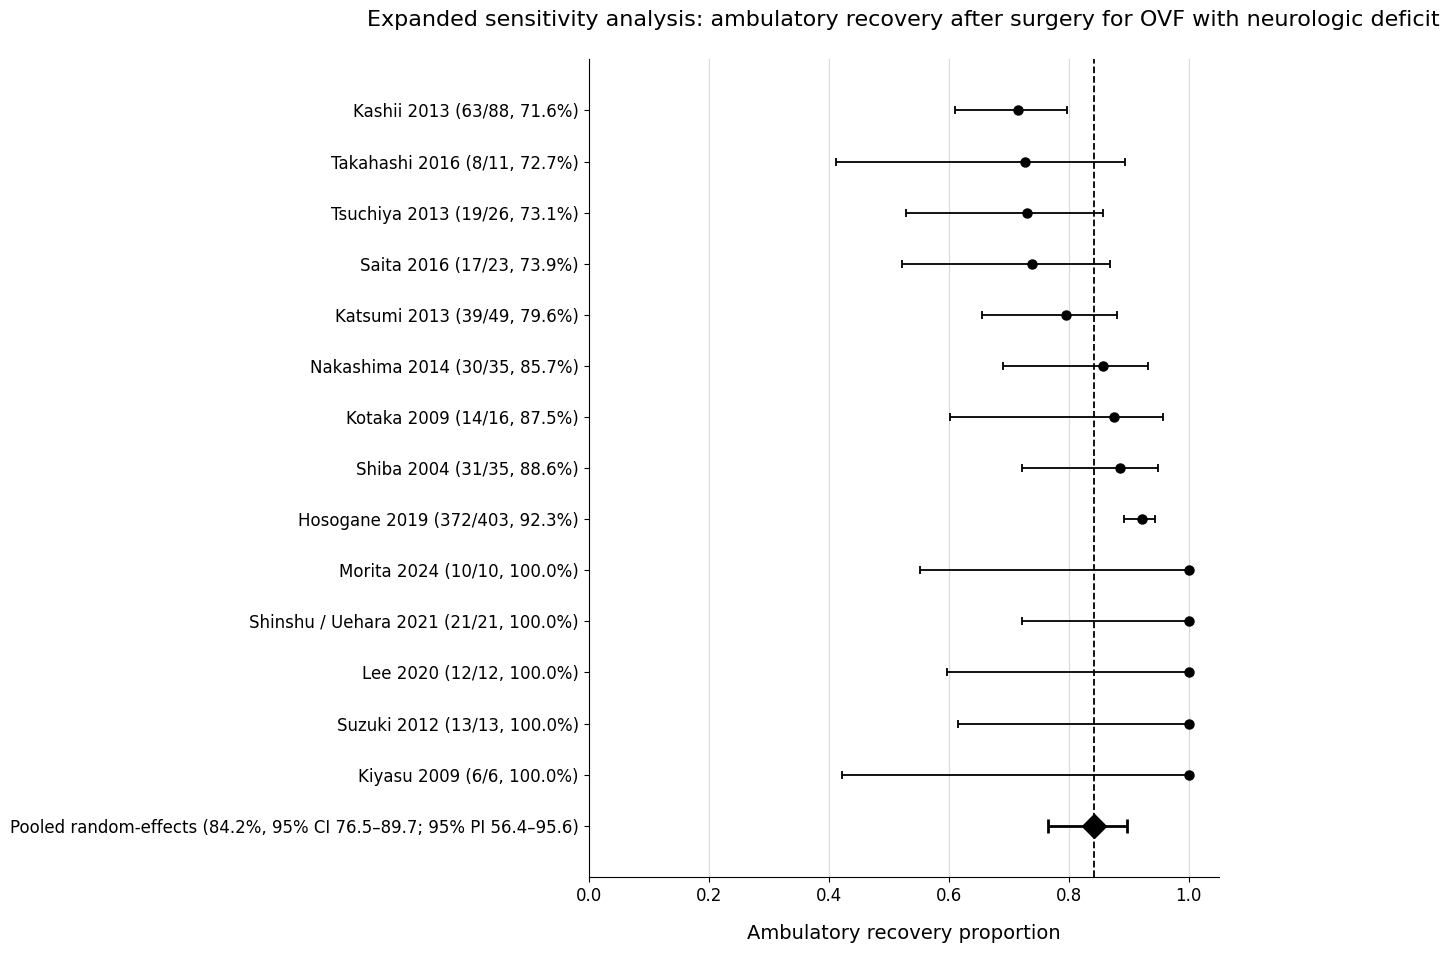

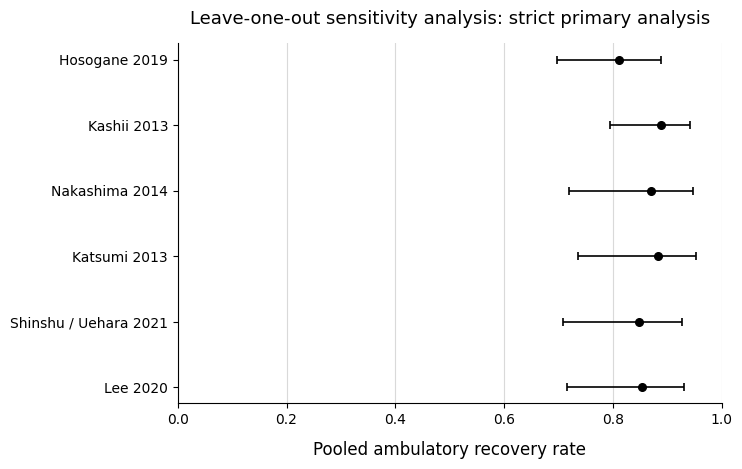

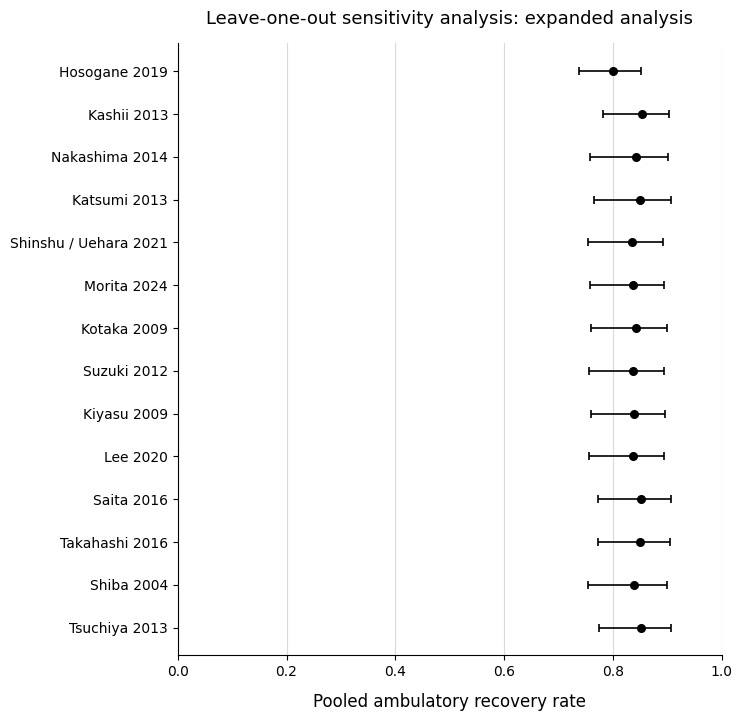


Expanded analysis Egger's regression test
Intercept = 0.175
SE = 0.879
t = 0.199
p = 0.846


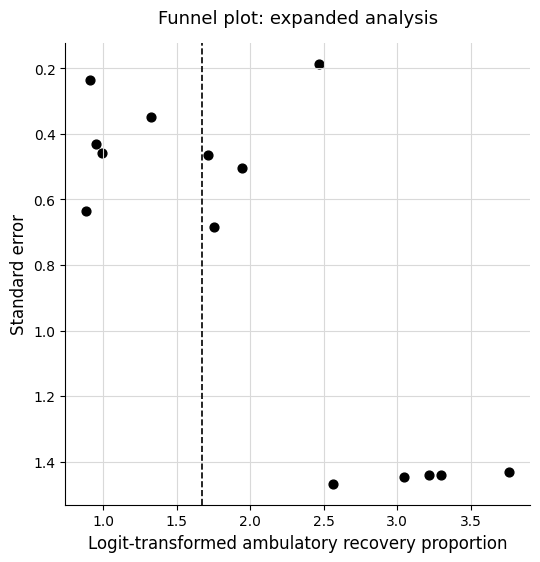


Strict analysis - exploratory only Egger's regression test
Intercept = 0.262
SE = 2.127
t = 0.123
p = 0.908

Saved files:
/content/OVF_meta_analysis_results.xlsx

Main figures:
/content/OVF_forest_strict_main.png
/content/OVF_forest_strict_main.pdf
/content/OVF_forest_expanded_sensitivity.png
/content/OVF_forest_expanded_sensitivity.pdf

Supplementary Figure S1:
/content/OVF_funnel_plot_expanded.png
/content/OVF_funnel_plot_expanded.pdf

Supplementary Figure S2:
/content/OVF_leave_one_out_strict.png
/content/OVF_leave_one_out_strict.pdf
/content/OVF_leave_one_out_expanded.png
/content/OVF_leave_one_out_expanded.pdf


In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# =========================
# 1. Load Excel file
# =========================
input_path = "/content/OVF_BJJ_meta_ready.xlsx"

df = pd.read_excel(input_path, sheet_name="analysis_inputs")
df = df.dropna(subset=["Study", "n", "events"])

df["n"] = df["n"].astype(float)
df["events"] = df["events"].astype(float)

df["strict"] = df["Use in strict main?"].eq("YES")
df["expanded"] = df["Use in expanded sensitivity?"].eq("YES")


# =========================
# 2. Random-effects meta-analysis
# =========================
def inv_logit(x):
    return 1 / (1 + np.exp(-x))


def meta_logit_dl(subdf):
    sub = subdf.copy().reset_index(drop=True)

    x = sub["events"].astype(float).values
    n = sub["n"].astype(float).values

    # Continuity correction for 0% or 100% studies
    x_cc = x + 0.5
    non_cc = (n - x) + 0.5

    yi = np.log(x_cc / non_cc)
    vi = 1 / x_cc + 1 / non_cc

    wi_fixed = 1 / vi
    y_fixed = np.sum(wi_fixed * yi) / np.sum(wi_fixed)

    Q = np.sum(wi_fixed * (yi - y_fixed) ** 2)
    k = len(yi)
    df_q = k - 1

    C = np.sum(wi_fixed) - (np.sum(wi_fixed ** 2) / np.sum(wi_fixed))
    tau2 = max(0, (Q - df_q) / C) if C > 0 else 0

    wi_random = 1 / (vi + tau2)

    y_pool = np.sum(wi_random * yi) / np.sum(wi_random)
    se_pool = math.sqrt(1 / np.sum(wi_random))

    pooled = float(inv_logit(y_pool))
    ci_low = float(inv_logit(y_pool - 1.96 * se_pool))
    ci_high = float(inv_logit(y_pool + 1.96 * se_pool))

    # 95% prediction interval on logit scale
    pi_low = float(inv_logit(y_pool - 1.96 * np.sqrt(tau2 + se_pool**2)))
    pi_high = float(inv_logit(y_pool + 1.96 * np.sqrt(tau2 + se_pool**2)))

    I2 = max(0, (Q - df_q) / Q) * 100 if Q > 0 else 0

    sub["rate"] = x / n
    sub["yi"] = yi
    sub["vi"] = vi
    sub["sei"] = np.sqrt(vi)
    sub["weight_random"] = wi_random / np.sum(wi_random)

    sub["ci_low"] = inv_logit(yi - 1.96 * np.sqrt(vi))
    sub["ci_high"] = inv_logit(yi + 1.96 * np.sqrt(vi))

    sub["ci_low_plot"] = np.minimum(sub["ci_low"], sub["rate"])
    sub["ci_high_plot"] = np.maximum(sub["ci_high"], sub["rate"])

    result = {
        "k": k,
        "events_total": int(np.sum(x)),
        "n_total": int(np.sum(n)),
        "crude_rate": float(np.sum(x) / np.sum(n)),
        "pooled_rate": pooled,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "pi_low": pi_low,
        "pi_high": pi_high,
        "tau2": float(tau2),
        "Q": float(Q),
        "df": int(df_q),
        "I2": float(I2),
    }

    return sub, result


# =========================
# 3. Leave-one-out analysis
# =========================
def leave_one_out(subdf):
    rows = []

    for i, study in enumerate(subdf["Study"]):
        tmp = subdf.drop(subdf.index[i])
        _, res = meta_logit_dl(tmp)

        rows.append({
            "Omitted study": study,
            "k": res["k"],
            "pooled_rate": res["pooled_rate"],
            "ci_low": res["ci_low"],
            "ci_high": res["ci_high"],
            "pi_low": res["pi_low"],
            "pi_high": res["pi_high"],
            "I2": res["I2"],
        })

    return pd.DataFrame(rows)


# =========================
# 4. Forest plot
# =========================
def plot_forest(sub, res, title, outpath):
    plot_df = sub.copy().reset_index(drop=True)

    plot_df["study_year"] = (
        plot_df["Study"]
        .astype(str)
        .str.extract(r"(\d{4})")
        .astype(float)
    )

    plot_df = plot_df.sort_values(
        by=["rate", "study_year"],
        ascending=[False, True]
    ).reset_index(drop=True)

    plot_df = plot_df.iloc[::-1].reset_index(drop=True)

    n_studies = len(plot_df)
    study_y = np.arange(n_studies, 0, -1)
    pooled_y = 0

    rates = plot_df["rate"].values
    low = plot_df["ci_low_plot"].values
    high = plot_df["ci_high_plot"].values

    xerr_low = np.maximum(0, rates - low)
    xerr_high = np.maximum(0, high - rates)

    fig_height = max(7, 0.55 * n_studies + 3.2)
    fig, ax = plt.subplots(figsize=(10.5, fig_height))

    ax.errorbar(
        rates,
        study_y,
        xerr=[xerr_low, xerr_high],
        fmt="o",
        color="black",
        ecolor="black",
        elinewidth=1.3,
        markersize=6.5,
        capsize=3,
        capthick=1.3
    )

    ax.axvline(
        res["pooled_rate"],
        linestyle="--",
        linewidth=1.3,
        color="black"
    )

    ax.errorbar(
        res["pooled_rate"],
        pooled_y,
        xerr=[
            [max(0, res["pooled_rate"] - res["ci_low"])],
            [max(0, res["ci_high"] - res["pooled_rate"])]
        ],
        fmt="D",
        color="black",
        ecolor="black",
        elinewidth=2.0,
        markersize=12,
        capsize=5,
        capthick=2.0
    )

    labels = [
        f"{row['Study']} ({int(row['events'])}/{int(row['n'])}, {row['rate']*100:.1f}%)"
        for _, row in plot_df.iterrows()
    ]

    pooled_label = (
        f"Pooled random-effects ({res['pooled_rate']*100:.1f}%, "
        f"95% CI {res['ci_low']*100:.1f}–{res['ci_high']*100:.1f}; "
        f"95% PI {res['pi_low']*100:.1f}–{res['pi_high']*100:.1f})"
    )

    ax.set_yticks(list(study_y) + [pooled_y])
    ax.set_yticklabels(labels + [pooled_label], fontsize=12)

    ax.set_ylim(-1, n_studies + 1)
    ax.set_xlim(0, 1.05)

    ax.set_xlabel("Ambulatory recovery proportion", fontsize=14, labelpad=14)
    ax.set_title(title, fontsize=16, pad=24)

    ax.tick_params(axis="x", labelsize=12)
    ax.grid(axis="x", color="0.85", linewidth=0.8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.subplots_adjust(left=0.38, right=0.98, top=0.88, bottom=0.13)

    fig.savefig(outpath, dpi=600, bbox_inches="tight")
    fig.savefig(outpath.replace(".png", ".pdf"), bbox_inches="tight")

    plt.show()


# =========================
# 5. Leave-one-out forest plot
# =========================
def plot_leave_one_out(loo_df, title, outpath):
    plot_df = loo_df.copy().reset_index(drop=True)
    plot_df = plot_df.iloc[::-1].reset_index(drop=True)

    y = np.arange(len(plot_df))
    rates = plot_df["pooled_rate"].values
    low = plot_df["ci_low"].values
    high = plot_df["ci_high"].values

    xerr_low = np.maximum(0, rates - low)
    xerr_high = np.maximum(0, high - rates)

    fig_height = max(5, 0.45 * len(plot_df) + 2.2)
    fig, ax = plt.subplots(figsize=(8.5, fig_height))

    ax.errorbar(
        rates,
        y,
        xerr=[xerr_low, xerr_high],
        fmt="o",
        color="black",
        ecolor="black",
        elinewidth=1.2,
        markersize=5.5,
        capsize=3,
        capthick=1.2
    )

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["Omitted study"], fontsize=10)

    ax.set_xlim(0, 1.0)
    ax.set_xlabel("Pooled ambulatory recovery rate", fontsize=12, labelpad=10)
    ax.set_title(title, fontsize=13, pad=14)

    ax.tick_params(axis="x", labelsize=10)
    ax.grid(axis="x", color="0.85", linewidth=0.8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.subplots_adjust(left=0.34, right=0.98, top=0.88, bottom=0.16)

    fig.savefig(outpath, dpi=600, bbox_inches="tight")
    fig.savefig(outpath.replace(".png", ".pdf"), bbox_inches="tight")

    plt.show()


# =========================
# 6. Egger's regression test
# =========================
def egger_test(meta_df, label="Expanded analysis"):
    yi = meta_df["yi"].values
    sei = np.sqrt(meta_df["vi"].values)

    snd = yi / sei
    precision = 1 / sei

    X = sm.add_constant(precision)
    model = sm.OLS(snd, X).fit()

    intercept = model.params[0]
    intercept_se = model.bse[0]
    t_value = model.tvalues[0]
    p_value = model.pvalues[0]

    print(f"\n{label} Egger's regression test")
    print(f"Intercept = {intercept:.3f}")
    print(f"SE = {intercept_se:.3f}")
    print(f"t = {t_value:.3f}")
    print(f"p = {p_value:.3f}")

    return {
        "Analysis": label,
        "Egger intercept": intercept,
        "SE": intercept_se,
        "t": t_value,
        "p": p_value,
    }


# =========================
# 7. Funnel plot
# =========================
def funnel_plot(meta_df, res, title, outpath):
    yi = meta_df["yi"].values
    sei = np.sqrt(meta_df["vi"].values)

    pooled_logit = np.log(
        (res["pooled_rate"] + 1e-9) / (1 - res["pooled_rate"] + 1e-9)
    )

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(yi, sei, color="black", s=40)

    ax.axvline(
        pooled_logit,
        linestyle="--",
        color="black",
        linewidth=1.2
    )

    ax.invert_yaxis()

    ax.set_xlabel("Logit-transformed ambulatory recovery proportion", fontsize=12)
    ax.set_ylabel("Standard error", fontsize=12)
    ax.set_title(title, fontsize=13, pad=14)

    ax.grid(color="0.85", linewidth=0.8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.savefig(outpath, dpi=600, bbox_inches="tight")
    fig.savefig(outpath.replace(".png", ".pdf"), bbox_inches="tight")

    plt.show()


# =========================
# 8. Run analyses
# =========================
strict_df, strict_res = meta_logit_dl(df[df["strict"]])
expanded_df, expanded_res = meta_logit_dl(df[df["expanded"]])

strict_loo = leave_one_out(strict_df)
expanded_loo = leave_one_out(expanded_df)

print("Strict main analysis")
print(strict_res)

print("\nExpanded sensitivity analysis")
print(expanded_res)

print("\nPrediction intervals")
print(
    f"Strict analysis: pooled {strict_res['pooled_rate']*100:.1f}% "
    f"(95% CI {strict_res['ci_low']*100:.1f}–{strict_res['ci_high']*100:.1f}; "
    f"95% PI {strict_res['pi_low']*100:.1f}–{strict_res['pi_high']*100:.1f})"
)

print(
    f"Expanded analysis: pooled {expanded_res['pooled_rate']*100:.1f}% "
    f"(95% CI {expanded_res['ci_low']*100:.1f}–{expanded_res['ci_high']*100:.1f}; "
    f"95% PI {expanded_res['pi_low']*100:.1f}–{expanded_res['pi_high']*100:.1f})"
)


# =========================
# 9. Main forest plots
# =========================
plot_forest(
    strict_df,
    strict_res,
    "Strict main analysis: ambulatory recovery after surgery for OVF with neurologic deficit",
    "/content/OVF_forest_strict_main.png"
)

plot_forest(
    expanded_df,
    expanded_res,
    "Expanded sensitivity analysis: ambulatory recovery after surgery for OVF with neurologic deficit",
    "/content/OVF_forest_expanded_sensitivity.png"
)


# =========================
# 10. Supplementary Figure S2
# =========================
plot_leave_one_out(
    strict_loo,
    "Leave-one-out sensitivity analysis: strict primary analysis",
    "/content/OVF_leave_one_out_strict.png"
)

plot_leave_one_out(
    expanded_loo,
    "Leave-one-out sensitivity analysis: expanded analysis",
    "/content/OVF_leave_one_out_expanded.png"
)


# =========================
# 11. Egger's test + Supplementary Figure S1
# =========================
egger_expanded = egger_test(
    expanded_df,
    "Expanded analysis"
)

funnel_plot(
    expanded_df,
    expanded_res,
    "Funnel plot: expanded analysis",
    "/content/OVF_funnel_plot_expanded.png"
)

# Exploratory only; underpowered because k = 6
egger_strict = egger_test(
    strict_df,
    "Strict analysis - exploratory only"
)


# =========================
# 12. Save Excel outputs
# =========================
pooled_results = pd.DataFrame([
    {"Analysis": "Strict main", **strict_res},
    {"Analysis": "Expanded sensitivity", **expanded_res},
])

egger_results = pd.DataFrame([
    egger_expanded,
    egger_strict,
])

with pd.ExcelWriter("/content/OVF_meta_analysis_results.xlsx") as writer:
    pooled_results.to_excel(writer, sheet_name="pooled_results", index=False)
    strict_df.to_excel(writer, sheet_name="strict_forest_data", index=False)
    expanded_df.to_excel(writer, sheet_name="expanded_forest_data", index=False)
    strict_loo.to_excel(writer, sheet_name="strict_leave_one_out", index=False)
    expanded_loo.to_excel(writer, sheet_name="expanded_leave_one_out", index=False)
    egger_results.to_excel(writer, sheet_name="egger_test", index=False)


# =========================
# 13. Final output list
# =========================
print("\nSaved files:")
print("/content/OVF_meta_analysis_results.xlsx")

print("\nMain figures:")
print("/content/OVF_forest_strict_main.png")
print("/content/OVF_forest_strict_main.pdf")
print("/content/OVF_forest_expanded_sensitivity.png")
print("/content/OVF_forest_expanded_sensitivity.pdf")

print("\nSupplementary Figure S1:")
print("/content/OVF_funnel_plot_expanded.png")
print("/content/OVF_funnel_plot_expanded.pdf")

print("\nSupplementary Figure S2:")
print("/content/OVF_leave_one_out_strict.png")
print("/content/OVF_leave_one_out_strict.pdf")
print("/content/OVF_leave_one_out_expanded.png")
print("/content/OVF_leave_one_out_expanded.pdf")